In [1]:
import numpy as np
import pandas as pd
from sea_urchin import SeaUrchin
import sea_urchin
import MDAnalysis as mda
import matplotlib.pyplot as plt


/tmp/ipykernel_1085330/2947918862.py:3: UserWarning: IRA (Iterative Rotations Assignments) not found. Some advanced alignment features may not be available. See installation documentation for setup instructions.
  from sea_urchin import SeaUrchin
/global/cfs/cdirs/m4248/xiaoxusr/miniconda3/envs/sea_urchin/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
import logging
import sea_urchin
import sys

# Make old module path resolve to the current package
sys.modules["sea_urchin.sea_urchin"] = sea_urchin

# (optional but often needed) if the pickle references submodules
try:
    import sea_urchin.core
    sys.modules["sea_urchin.sea_urchin.core"] = sea_urchin.core
except Exception:
    pass

# OldSetState = getattr(sea_urchin.SeaUrchin, "__setstate__", None)

# def compat_setstate(self, state):
#     # restore state the usual way
#     if OldSetState is not None:
#         OldSetState(self, state)
#     else:
#         # most pickles store a dict state
#         if isinstance(state, dict):
#             self.__dict__.update(state)
#         else:
#             # fallback if state format is unusual
#             self.__dict__.update(getattr(state, "__dict__", {}))

#     # add missing runtime-only attrs
#     if not hasattr(self, "logger"):
#         self.logger = logging.getLogger("SeaUrchin")

# sea_urchin.SeaUrchin.__setstate__ = compat_setstate

In [3]:
def get_index(value_list, value):
    # All indices of 0
    idx_all = [i for i, v in enumerate(value_list) if v == value]
    return idx_all

In [4]:
from collections import Counter
from tqdm import tqdm
def get_sites_data(clusters):
    n_F_list, n_O_list, F_O_ratio_list = [], [], []
    atom_id_list = []
    timestep_list = []
    for clu in tqdm(clusters):
        atom_id = clu.info["ori_idx"][get_index(clu.info["ato_typ"],0)[0]]+1
        positions = clu.get_positions()
        F_idx_list = get_index(clu.get_chemical_symbols(),"F")
        O_idx_list = get_index(clu.get_chemical_symbols(),"O") 
        na_idx = get_index(clu.get_chemical_symbols(),"Na")[0]
        na_position = positions[na_idx]
        f_positions = positions[F_idx_list]
        o_positions = positions[O_idx_list]
        distance_f_vectors = f_positions-na_position
        distance_o_vectors = o_positions-na_position
        distance_f = np.linalg.norm(distance_f_vectors,axis=1)
        distance_o = np.linalg.norm(distance_o_vectors,axis=1)
        f_idx = [i for i, d in enumerate(distance_f) if d < 3]
        o_idx = [i for i, d in enumerate(distance_o) if d < 3]
        n_F = len(f_idx)
        n_O = len(o_idx)
        
        atom_id_list.append(atom_id)
        timestep_list.append(clu.info["timestamp"])
        F_O_ratio = n_F/n_O
        n_F_list.append(n_F)
        n_O_list.append(n_O)
        F_O_ratio_list.append(F_O_ratio)
    sites_dict = {
        "clu_idx": range(len(clusters)),
        "atom_id": atom_id_list,
        "timestep": timestep_list,
        "n_F": n_F_list,
        "n_O": n_O_list,
        "F_O_ratio": F_O_ratio_list
    }
    return sites_dict

In [5]:
from collections import Counter
from tqdm import tqdm
def get_more_sites_data(clusters, tetramer_O_idx_total, glyme_O_idx_total):
    n_F_list, n_tetramer_O_list, n_glyme_O_list = [], [], []
    atom_id_list = []
    timestep_list = []
    for clu in tqdm(clusters):
        positions = clu.get_positions()
        # we get the idx of different atoms within the cluster
        F_idx_list = get_index(clu.get_chemical_symbols(),"F")
        O_idx_list = get_index(clu.get_chemical_symbols(),"O") 
        na_idx = get_index(clu.get_chemical_symbols(),"Na")[0]
        na_id = na_idx+1
        
        # we get the ori_idx of atoms in data file
        na_ori_idx = clu.info["ori_idx"][na_idx] 
        f_ori_idx = [clu.info["ori_idx"][i] for i in F_idx_list]
        o_ori_idx = [clu.info["ori_idx"][i] for i in O_idx_list]
        
        # get each atoms' positions
        na_position = positions[na_idx]
        f_positions = positions[F_idx_list]
        o_positions = positions[O_idx_list]
        
        # get distance to Na+
        distance_f_vectors = f_positions-na_position
        distance_o_vectors = o_positions-na_position
        distance_f = np.linalg.norm(distance_f_vectors,axis=1)
        distance_o = np.linalg.norm(distance_o_vectors,axis=1)
        
        # choose atoms within 4 Angstrom to Na+
        f_ori_idx_sol = [f_ori_idx[i] for i, d in enumerate(distance_f) if d < 3] # ori_idx within cutoff in data file
        o_ori_idx_sol= [o_ori_idx[i] for i, d in enumerate(distance_o) if d < 3] # ori_idx within cutoff in data file
        
        tetramer_O_idx = [i for i in o_ori_idx_sol if i in tetramer_O_idx_total]
        glyme_O_idx = [i for i in o_ori_idx_sol if i in glyme_O_idx_total]
        
        n_F = len(f_ori_idx_sol)
        n_tetramer_O = len(tetramer_O_idx)
        n_glyme_O = len(glyme_O_idx)

        
        atom_id_list.append(na_ori_idx+1)
        timestep_list.append(clu.info["timestamp"])
        n_F_list.append(n_F)
        n_tetramer_O_list.append(n_tetramer_O)
        n_glyme_O_list.append(n_glyme_O)

    sites_dict = {
        "clu_idx": range(len(clusters)),
        "atom_id": atom_id_list,
        "timestep": timestep_list,
        "n_F": n_F_list,
        "n_tetramer_O": n_tetramer_O_list,
        "n_glyme_O": n_glyme_O_list
    }
    return sites_dict

In [6]:
def get_idx_data(u):
    resid_name={}
    resid_name = {
        # "dee": [],
        "glyme": [],
        "Na+": [],
        "tetramer": []
    }
    # resid_name["dee"]=[]
    for res in u.residues.ix:
        res_id = res+1
        num_atom = len(u.select_atoms(f"resid {res_id}"))
        # if num_atom==15:
        #     resid_name["dee"].append(res_id)
        if num_atom==16:
            resid_name["glyme"].append(res_id)
        elif num_atom==1:
            resid_name["Na+"].append(res_id)
        else:
            resid_name["tetramer"].append(res_id)
    glyme_resid = ""
    for i in resid_name["glyme"]:
        glyme_resid += f"{i} "
    tetramer_resid = ""
    for i in resid_name["tetramer"]:
        tetramer_resid += f"{i} "
    glyme = u.select_atoms(f"resid {glyme_resid}")
    tetramer = u.select_atoms(f"resid {tetramer_resid}")
    tetramer_O = tetramer.select_atoms("type 10") # O sites of tetramer
    glyme_O = glyme.select_atoms("type 2") # O of glyme
    tetramer_O_idx = tetramer_O.atoms.ix
    glyme_O_idx = glyme_O.atoms.ix
    return tetramer_O_idx, glyme_O_idx

### [4O:Na]G1

In [12]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/glyme_tetramer_8_1/results_restart/clusters/urchin_Na_full_mol.pkl"
obj_8_1 = sea_urchin.SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [13]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/long_run_09102025/glyme_tetramer_8_1/results_restart/clusters/urchin_Na_full_mol.pkl"
obj_8_2 = SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [14]:
clusters_8 = obj_8_1.clusters+obj_8_2.clusters[256:]

In [15]:
u_8_0 = mda.Universe("/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/glyme_tetramer_8_1/results_restart/lammps.data")

In [16]:
tetramer_O_idx_8, glyme_O_idx_8 = get_idx_data(u_8_0)

In [17]:
more_sites_dict_8 = get_more_sites_data(clusters_8, tetramer_O_idx_8, glyme_O_idx_8)

100%|██████████| 128256/128256 [00:27<00:00, 4718.00it/s]


In [18]:
more_sites_df_8 = pd.DataFrame(more_sites_dict_8)

In [19]:
more_sites_df_8.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O
0,0,242,0,0,0,6
1,1,243,0,0,5,0
2,2,244,0,0,3,2
3,3,245,0,0,4,2
4,4,487,0,0,3,3


In [20]:
import numpy as np

cond_structural = (more_sites_df_8["n_glyme_O"] == 1) & (more_sites_df_8["n_tetramer_O"] >= 4) | (more_sites_df_8["n_glyme_O"] == 0)
cond_ssip       = (more_sites_df_8["n_tetramer_O"] == 1) & (more_sites_df_8["n_glyme_O"] >= 4) | (more_sites_df_8["n_tetramer_O"] == 0)

more_sites_df_8["cluster_type"] = np.select(
    [cond_structural, cond_ssip],
    ["structural", "solvent-separated-ion-pairs"],
    default="contact-ion-pairs",
)

In [21]:
more_sites_df_8.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O,cluster_type
0,0,242,0,0,0,6,solvent-separated-ion-pairs
1,1,243,0,0,5,0,structural
2,2,244,0,0,3,2,contact-ion-pairs
3,3,245,0,0,4,2,contact-ion-pairs
4,4,487,0,0,3,3,contact-ion-pairs


In [27]:
SSIP = clusters_8[0]

In [29]:
CIP = clusters_8[2]

In [31]:
structrual = clusters_8[1]

In [34]:
SSIP.write("./cluster_classification/ssip.xyz")

In [35]:
CIP.write("./cluster_classification/cip.xyz")

In [33]:
structrual.write("./cluster_classification/structrual.xyz")

In [220]:
counts_8 = more_sites_df_8["cluster_type"].value_counts(dropna=False)
counts_8

cluster_type
contact-ion-pairs              96057
structural                     27971
solvent-separated-ion-pairs     4228
Name: count, dtype: int64

### [3O:Na]G1

In [149]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/glyme_tetramer_6_1/results_restart/clusters/urchin_Na_full_mol.pkl"
obj_6_1 = SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [150]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/long_run_09102025/glyme_tetramer_6_1/results_restart/clusters/urchin_Na_full_mol.pkl"
obj_6_2 = SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [151]:
clusters_6 = obj_6_1.clusters+obj_6_2.clusters[256:]

In [152]:
u_6_0 = mda.Universe("/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/glyme_tetramer_6_1/results_restart/lammps.data")

In [153]:
tetramer_O_idx_6, glyme_O_idx_6 = get_idx_data(u_6_0)

In [154]:
more_sites_dict_6 = get_more_sites_data(clusters_6, tetramer_O_idx_6, glyme_O_idx_6)

100%|██████████| 128256/128256 [00:28<00:00, 4428.36it/s]


In [155]:
more_sites_df_6 = pd.DataFrame(more_sites_dict_6)

In [156]:
more_sites_df_6.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O
0,0,210,0,0,3,3
1,1,211,0,0,5,0
2,2,212,0,0,6,0
3,3,213,0,0,3,3
4,4,423,0,0,5,1


In [221]:
import numpy as np

cond_structural = (more_sites_df_6["n_glyme_O"] == 1) & (more_sites_df_6["n_tetramer_O"] >= 4) | (more_sites_df_6["n_glyme_O"] == 0)
cond_ssip       = (more_sites_df_6["n_tetramer_O"] == 1) & (more_sites_df_6["n_glyme_O"] >= 4) | (more_sites_df_6["n_tetramer_O"] == 0)

more_sites_df_6["cluster_type"] = np.select(
    [cond_structural, cond_ssip],
    ["structural", "solvent-separated-ion-pairs"],
    default="contact-ion-pairs",
)

In [222]:
more_sites_df_6.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O,cluster_type
0,0,210,0,0,3,3,contact-ion-pairs
1,1,211,0,0,5,0,structural
2,2,212,0,0,6,0,structural
3,3,213,0,0,3,3,contact-ion-pairs
4,4,423,0,0,5,1,structural


In [223]:
counts_6 = more_sites_df_6["cluster_type"].value_counts(dropna=False)
counts_6

cluster_type
contact-ion-pairs              92166
structural                     33383
solvent-separated-ion-pairs     2707
Name: count, dtype: int64

### [2O:Na]G1

In [173]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/glyme_tetramer_4_1/results_restart/clusters/urchin_Na_full_mol.pkl"
obj_4_1 = SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [174]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/long_run_09102025/glyme_tetramer_4_1/results_restart/clusters/urchin_Na_full_mol.pkl"
obj_4_2 = SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [175]:
clusters_4 = obj_4_1.clusters+obj_4_2.clusters[256:]

In [176]:
u_4_0 = mda.Universe("/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/glyme_tetramer_4_1/results_restart/lammps.data")

In [177]:
tetramer_O_idx_4, glyme_O_idx_4 = get_idx_data(u_4_0)

In [178]:
more_sites_dict_4 = get_more_sites_data(clusters_4, tetramer_O_idx_4, glyme_O_idx_4)

100%|██████████| 128256/128256 [00:27<00:00, 4674.09it/s]


In [179]:
more_sites_df_4 = pd.DataFrame(more_sites_dict_4)

In [180]:
more_sites_df_4.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O
0,0,178,0,0,2,4
1,1,179,0,1,3,2
2,2,180,0,1,6,0
3,3,181,0,0,4,1
4,4,359,0,0,1,5


In [224]:
import numpy as np

cond_structural = (more_sites_df_4["n_glyme_O"] == 1) & (more_sites_df_4["n_tetramer_O"] >= 4) | (more_sites_df_4["n_glyme_O"] == 0)
cond_ssip       = (more_sites_df_4["n_tetramer_O"] == 1) & (more_sites_df_4["n_glyme_O"] >= 4) | (more_sites_df_4["n_tetramer_O"] == 0)

more_sites_df_4["cluster_type"] = np.select(
    [cond_structural, cond_ssip],
    ["structural", "solvent-separated-ion-pairs"],
    default="contact-ion-pairs",
)

In [225]:
more_sites_df_4.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O,cluster_type
0,0,178,0,0,2,4,contact-ion-pairs
1,1,179,0,1,3,2,contact-ion-pairs
2,2,180,0,1,6,0,structural
3,3,181,0,0,4,1,structural
4,4,359,0,0,1,5,solvent-separated-ion-pairs


In [226]:
counts_4 = more_sites_df_4["cluster_type"].value_counts(dropna=False)
counts_4

cluster_type
contact-ion-pairs              80025
structural                     46772
solvent-separated-ion-pairs     1459
Name: count, dtype: int64

### [1O:Na]G1

In [184]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/glyme_tetramer_2_1/results_restart/clusters/urchin_Na_full_mol.pkl"
obj_2_1 = SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [185]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/long_run_09102025/glyme_tetramer_2_1/results_restart/clusters/urchin_Na_full_mol.pkl"
obj_2_2 = SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [186]:
clusters_2 = obj_2_1.clusters+obj_2_2.clusters[256:]

In [187]:
u_2_0 = mda.Universe("/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/classical_fix_momentum/glyme_tetramer_2_1/results_restart/lammps.data")

In [188]:
tetramer_O_idx_2, glyme_O_idx_2 = get_idx_data(u_2_0)

In [189]:
more_sites_dict_2 = get_more_sites_data(clusters_2, tetramer_O_idx_2, glyme_O_idx_2)

100%|██████████| 128256/128256 [00:31<00:00, 4091.36it/s]


In [190]:
more_sites_df_2 = pd.DataFrame(more_sites_dict_2)

In [191]:
more_sites_df_2.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O
0,0,146,0,0,3,2
1,1,147,0,0,4,0
2,2,148,0,3,3,0
3,3,149,0,1,4,0
4,4,295,0,2,4,0


In [227]:
import numpy as np

cond_structural = (more_sites_df_2["n_glyme_O"] == 1) & (more_sites_df_2["n_tetramer_O"] >= 4) | (more_sites_df_2["n_glyme_O"] == 0)
cond_ssip       = (more_sites_df_2["n_tetramer_O"] == 1) & (more_sites_df_2["n_glyme_O"] >= 4) | (more_sites_df_2["n_tetramer_O"] == 0)

more_sites_df_2["cluster_type"] = np.select(
    [cond_structural, cond_ssip],
    ["structural", "solvent-separated-ion-pairs"],
    default="contact-ion-pairs",
)

In [228]:
more_sites_df_2.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O,cluster_type
0,0,146,0,0,3,2,contact-ion-pairs
1,1,147,0,0,4,0,structural
2,2,148,0,3,3,0,structural
3,3,149,0,1,4,0,structural
4,4,295,0,2,4,0,structural


In [229]:
counts_2 = more_sites_df_2["cluster_type"].value_counts(dropna=False)
counts_2

cluster_type
structural                     72640
contact-ion-pairs              55223
solvent-separated-ion-pairs      393
Name: count, dtype: int64

### [4O:Na]G1 60C

In [8]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/60C/glyme_tetramer_8_1/results/clusters/urchin_Na.pkl"
obj_8_60C_1 = SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [9]:
file_path = "/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/60C/glyme_tetramer_8_1/long_run/results_restart/clusters/urchin_Na.pkl"
obj_8_60C_8_60C = SeaUrchin(file_path)


╔═════════════════════════════════════════════════════════════════════════════╗
║               ____               _   _          _     _                     ║
║              / ___|  ___  __ _  | | | |_ __ ___| |__ (_)_ __                ║
║              \___ \ / _ \/ _` | | | | | '__/ __| '_ \| | '_ \               ║
║               ___) |  __/ (_| | | |_| | | | (__| | | | | | | |              ║
║              |____/ \___|\__,_|  \___/|_|  \___|_| |_|_|_| |_|              ║
║                                                                             ║
║           ☼ Coordination environment classification of MD data ☼            ║
║                                                                             ║
║                          Version 1.1 | 15 Oct. 2025                         ║
║                 Materials Theory Group @ Molecular Foundry                  ║
╚═════════════════════════════════════════════════════════════════════════════╝

INFO: ☼ Ready to analyze molecular tra

In [10]:
clusters_8_60C = obj_8_60C_1.clusters+obj_8_60C_8_60C.clusters[256:]

In [11]:
u_8_60C_0 = mda.Universe("/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/60C/glyme_tetramer_8_1/results/lammps.data")

In [12]:
tetramer_O_idx_8_60C, glyme_O_idx_8_60C = get_idx_data(u_8_60C_0)

In [13]:
more_sites_dict_8_60C = get_more_sites_data(clusters_8_60C, tetramer_O_idx_8_60C, glyme_O_idx_8_60C)

100%|██████████| 128256/128256 [00:27<00:00, 4747.99it/s]


In [14]:
more_sites_df_8_60C = pd.DataFrame(more_sites_dict_8_60C)

In [15]:
more_sites_df_8_60C.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O
0,0,242,0,0,3,2
1,1,243,0,0,5,1
2,2,244,0,0,2,4
3,3,245,0,0,4,2
4,4,487,0,0,4,0


In [16]:
import numpy as np

cond_structural = (more_sites_df_8_60C["n_glyme_O"] == 1) & (more_sites_df_8_60C["n_tetramer_O"] >= 4) | (more_sites_df_8_60C["n_glyme_O"] == 0)
cond_ssip       = (more_sites_df_8_60C["n_tetramer_O"] == 1) & (more_sites_df_8_60C["n_glyme_O"] >= 4) | (more_sites_df_8_60C["n_tetramer_O"] == 0)

more_sites_df_8_60C["cluster_type"] = np.select(
    [cond_structural, cond_ssip],
    ["structural", "solvent-separated-ion-pairs"],
    default="contact-ion-pairs",
)

In [17]:
more_sites_df_8_60C.head()

,clu_idx,atom_id,timestep,n_F,n_tetramer_O,n_glyme_O,cluster_type
0,0,242,0,0,3,2,contact-ion-pairs
1,1,243,0,0,5,1,structural
2,2,244,0,0,2,4,contact-ion-pairs
3,3,245,0,0,4,2,contact-ion-pairs
4,4,487,0,0,4,0,structural


In [18]:
counts_8_60C = more_sites_df_8_60C["cluster_type"].value_counts(dropna=False)
counts_8_60C

cluster_type
contact-ion-pairs              92522
structural                     27886
solvent-separated-ion-pairs     7848
Name: count, dtype: int64

### Summary

In [230]:
index = ["structural Na","CIP Na", "SSIP Na"]
perc_cluster_each_family_8 = [
    counts_8["structural"]/len(more_sites_df_8),
    counts_8["contact-ion-pairs"]/len(more_sites_df_8),
    counts_8["solvent-separated-ion-pairs"]/len(more_sites_df_8)    
]
perc_cluster_each_family_8

[np.float64(0.2180872629740519),
 np.float64(0.7489474176646707),
 np.float64(0.032965319361277445)]

In [231]:
index = ["structural Na","CIP Na", "SSIP Na"]
perc_cluster_each_family_6 = [
    counts_6["structural"]/len(more_sites_df_6),
    counts_6["contact-ion-pairs"]/len(more_sites_df_6),
    counts_6["solvent-separated-ion-pairs"]/len(more_sites_df_6)
]
perc_cluster_each_family_6

[np.float64(0.26028411926147704),
 np.float64(0.7186096556886228),
 np.float64(0.0211062250499002)]

In [232]:
index = ["structural Na","CIP Na", "SSIP Na"]
perc_cluster_each_family_4 = [
    counts_4["structural"]/len(more_sites_df_4),
    counts_4["contact-ion-pairs"]/len(more_sites_df_4),
    counts_4["solvent-separated-ion-pairs"]/len(more_sites_df_4)
]
perc_cluster_each_family_4

[np.float64(0.3646768962075848),
 np.float64(0.6239474176646707),
 np.float64(0.01137568612774451)]

In [233]:
index = ["structural Na","CIP Na", "SSIP Na"]
perc_cluster_each_family_2 = [
    counts_2["structural"]/len(more_sites_df_2),
    counts_2["contact-ion-pairs"]/len(more_sites_df_2),
    counts_2["solvent-separated-ion-pairs"]/len(more_sites_df_2)
]
perc_cluster_each_family_2

[np.float64(0.5663672654690619),
 np.float64(0.4305685503992016),
 np.float64(0.003064184131736527)]

In [19]:
index = ["structural Na","CIP Na", "SSIP Na"]
perc_cluster_each_family_8_60C = [
    counts_8_60C["structural"]/len(more_sites_df_8_60C),
    counts_8_60C["contact-ion-pairs"]/len(more_sites_df_8_60C),
    counts_8_60C["solvent-separated-ion-pairs"]/len(more_sites_df_8_60C)
]
perc_cluster_each_family_8_60C

[np.float64(0.2174245259481038),
 np.float64(0.7213853542914171),
 np.float64(0.06119011976047904)]

(0.0, 1.0)

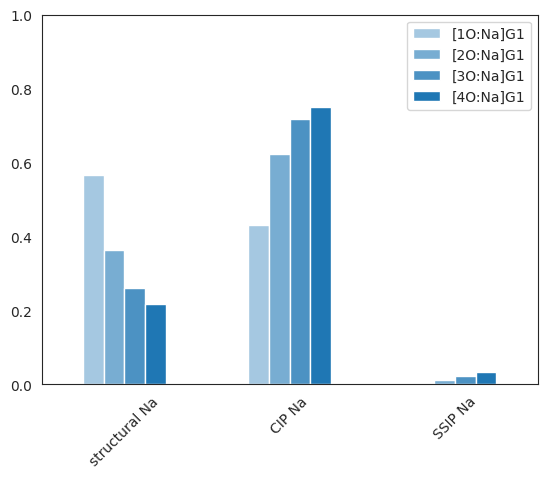

In [235]:

df = pd.DataFrame({
     '[1O:Na]G1': perc_cluster_each_family_2,
     '[2O:Na]G1': perc_cluster_each_family_4,
     '[3O:Na]G1': perc_cluster_each_family_6,            
     '[4O:Na]G1': perc_cluster_each_family_8,
     '60C[4O:Na]G1': perc_cluster_each_family_8_60C
                  }, index=index)
df.to_csv("G1_cluster_families_structural_cip_ssip.csv") 

import matplotlib.colors as mcolors
ax = df.plot.bar(
    rot=45,
    color=[
        mcolors.to_rgba('C0', 0.4),   # [4O:Na]G1
        mcolors.to_rgba('C0', 0.6),  # [3O:Na]G1
        mcolors.to_rgba('C0', 0.8),   # [2O:Na]G1
        mcolors.to_rgba('C0', 1.0)   # [1O:Na]G1
    ]
)
ax.set_ylim([0,1])